# Melbourne Bike Share – Predictive Modelling
## Bike Availability and Empty Dock Prediction using Gradient Boosting (XGBoost)

**Project 8: Urban Bike Sharing Demand Prediction with Graphical Learning**  
**Chameleon – MOP DS, AI & IoT | Deakin University T1 2026**  
**Author: Viswa Sai Mandava**

---

This notebook builds on the EDA and feature engineering completed previously.
It covers:
- Use Case 2: Predicting short-term bike availability (NBBIKES)
- Use Case 3: Predicting empty dock availability (NBEMPTYDOCKS)

Model used: **XGBoost Gradient Boosting Regressor**

## 1. Import Libraries

In [3]:
pip install xgboost

Note: you may need to restart the kernel to use updated packages.


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from xgboost import XGBRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import LabelEncoder
import warnings

warnings.filterwarnings('ignore')
plt.rcParams['figure.figsize'] = (12, 5)
sns.set_style('whitegrid')

print('Libraries loaded successfully')

Libraries loaded successfully


## 2. Load and Prepare the Dataset

In [6]:
df = pd.read_csv('74id-aqj9.csv', low_memory=False)

# Parse datetime
df['RUNDATE'] = df['RUNDATE'].astype(str)
df['datetime'] = pd.to_datetime(df['RUNDATE'], format='%Y%m%d%H%M%S', errors='coerce')

# Extract time features
df['hour']        = df['datetime'].dt.hour
df['day_of_week'] = df['datetime'].dt.dayofweek
df['month']       = df['datetime'].dt.month
df['year']        = df['datetime'].dt.year
df['is_weekend']  = df['day_of_week'].isin([5, 6]).astype(int)

# Drop rows with null datetime
df = df.dropna(subset=['datetime', 'NBBIKES', 'NBEMPTYDOCKS'])

print(f'Dataset shape after cleaning: {df.shape}')
print(f'Date range: {df["datetime"].min()} to {df["datetime"].max()}')
print(f'Unique stations: {df["NAME"].nunique()}')

Dataset shape after cleaning: (5644554, 22)
Date range: 2015-04-22 12:36:42 to 2018-09-04 10:00:10
Unique stations: 119


## 3. Feature Engineering – Lag and Rolling Features

We create lag features (previous readings) and rolling averages per station.
These capture the temporal history of each station and are the key inputs for the model.

In [8]:
# Sort by station and time
df = df.sort_values(['NAME', 'datetime']).reset_index(drop=True)

# Lag features for NBBIKES
for lag in [1, 2, 3, 6]:
    df[f'bikes_lag_{lag}'] = df.groupby('NAME')['NBBIKES'].shift(lag)
    df[f'docks_lag_{lag}'] = df.groupby('NAME')['NBEMPTYDOCKS'].shift(lag)

# Rolling mean (window=3) for NBBIKES and NBEMPTYDOCKS
df['bikes_roll_3'] = df.groupby('NAME')['NBBIKES'].transform(
    lambda x: x.shift(1).rolling(3, min_periods=1).mean())
df['docks_roll_3'] = df.groupby('NAME')['NBEMPTYDOCKS'].transform(
    lambda x: x.shift(1).rolling(3, min_periods=1).mean())

# Rolling mean (window=6)
df['bikes_roll_6'] = df.groupby('NAME')['NBBIKES'].transform(
    lambda x: x.shift(1).rolling(6, min_periods=1).mean())
df['docks_roll_6'] = df.groupby('NAME')['NBEMPTYDOCKS'].transform(
    lambda x: x.shift(1).rolling(6, min_periods=1).mean())

# Encode station name
le = LabelEncoder()
df['station_encoded'] = le.fit_transform(df['NAME'])

# Drop rows with NaN from lag features
df = df.dropna(subset=[f'bikes_lag_{l}' for l in [1,2,3,6]] +
                       [f'docks_lag_{l}' for l in [1,2,3,6]])

print(f'Shape after feature engineering: {df.shape}')
print('Lag and rolling features created successfully')

Shape after feature engineering: (5643885, 35)
Lag and rolling features created successfully


## 4. Define Features and Targets

In [10]:
feature_cols = [
    'hour', 'day_of_week', 'month', 'year', 'is_weekend',
    'station_encoded',
    'bikes_lag_1', 'bikes_lag_2', 'bikes_lag_3', 'bikes_lag_6',
    'docks_lag_1', 'docks_lag_2', 'docks_lag_3', 'docks_lag_6',
    'bikes_roll_3', 'bikes_roll_6',
    'docks_roll_3', 'docks_roll_6'
]

X = df[feature_cols]
y_bikes = df['NBBIKES']
y_docks = df['NBEMPTYDOCKS']

print(f'Feature matrix shape: {X.shape}')
print(f'Features used: {feature_cols}')

Feature matrix shape: (5643885, 18)
Features used: ['hour', 'day_of_week', 'month', 'year', 'is_weekend', 'station_encoded', 'bikes_lag_1', 'bikes_lag_2', 'bikes_lag_3', 'bikes_lag_6', 'docks_lag_1', 'docks_lag_2', 'docks_lag_3', 'docks_lag_6', 'bikes_roll_3', 'bikes_roll_6', 'docks_roll_3', 'docks_roll_6']


## 5. Train/Test Split

We use an 80/20 time-aware split — training on earlier data and testing on later data.
This avoids data leakage which would occur with a random split on time-series data.

In [12]:
split_idx = int(len(df) * 0.8)

X_train = X.iloc[:split_idx]
X_test  = X.iloc[split_idx:]

y_bikes_train = y_bikes.iloc[:split_idx]
y_bikes_test  = y_bikes.iloc[split_idx:]

y_docks_train = y_docks.iloc[:split_idx]
y_docks_test  = y_docks.iloc[split_idx:]

print(f'Training set size : {X_train.shape[0]:,}')
print(f'Test set size     : {X_test.shape[0]:,}')

Training set size : 4,515,108
Test set size     : 1,128,777


## 6. Use Case 2 – Bike Availability Prediction (XGBoost)

In [14]:
xgb_bikes = XGBRegressor(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1,
    verbosity=0
)

print('Training XGBoost model for Bike Availability...')
xgb_bikes.fit(X_train, y_bikes_train)

bikes_pred = xgb_bikes.predict(X_test)

mae_bikes  = mean_absolute_error(y_bikes_test, bikes_pred)
rmse_bikes = np.sqrt(mean_squared_error(y_bikes_test, bikes_pred))
r2_bikes   = r2_score(y_bikes_test, bikes_pred)

print(f'\n=== Bike Availability Prediction Results ===')
print(f'MAE  (Mean Absolute Error)       : {mae_bikes:.4f}')
print(f'RMSE (Root Mean Squared Error)   : {rmse_bikes:.4f}')
print(f'R²   (R-squared)                 : {r2_bikes:.4f}')

Training XGBoost model for Bike Availability...

=== Bike Availability Prediction Results ===
MAE  (Mean Absolute Error)       : 0.1363
RMSE (Root Mean Squared Error)   : 0.4823
R²   (R-squared)                 : 0.9901


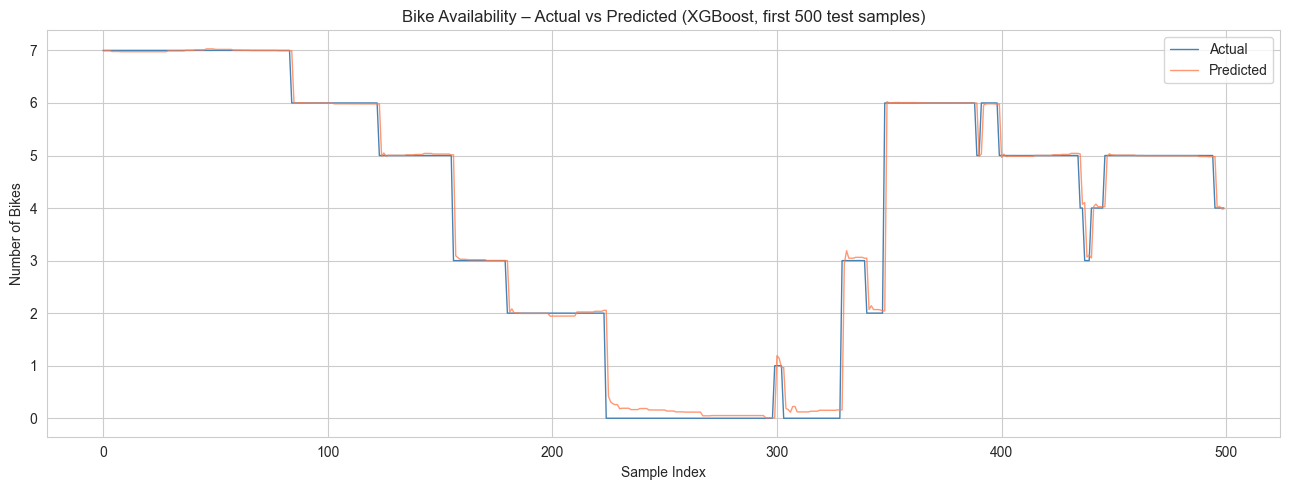

Plot saved.


In [15]:
# Plot actual vs predicted for a sample of 500 points
sample = 500
fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(y_bikes_test.values[:sample], label='Actual', color='steelblue', linewidth=1)
ax.plot(bikes_pred[:sample], label='Predicted', color='coral', linewidth=1, alpha=0.8)
ax.set_title('Bike Availability – Actual vs Predicted (XGBoost, first 500 test samples)')
ax.set_xlabel('Sample Index')
ax.set_ylabel('Number of Bikes')
ax.legend()
plt.tight_layout()
plt.savefig('bikes_actual_vs_predicted.png', dpi=150)
plt.show()
print('Plot saved.')

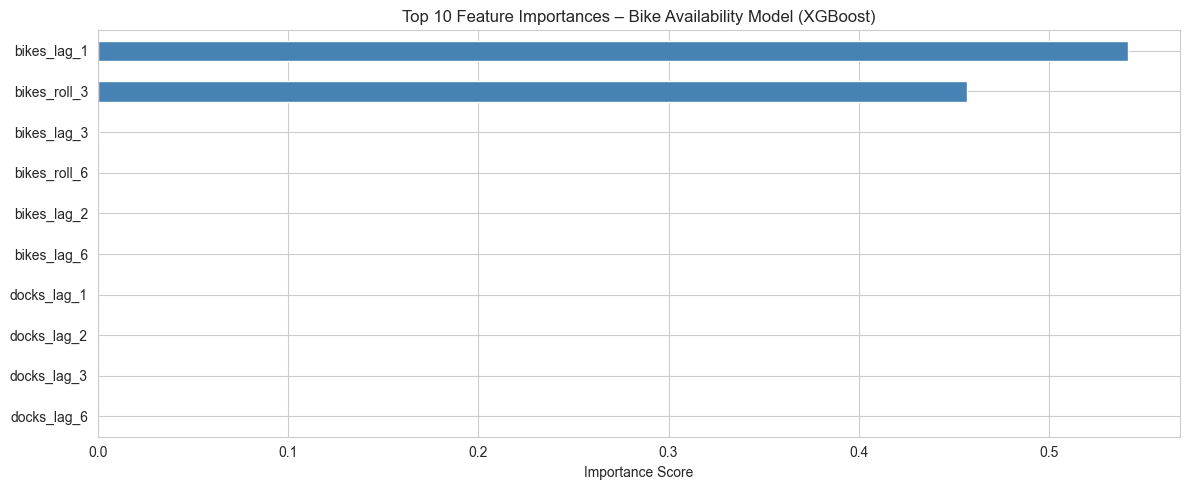

Plot saved.

Top 10 features:
bikes_lag_1     0.541699
bikes_roll_3    0.456692
bikes_lag_3     0.000556
bikes_roll_6    0.000234
bikes_lag_2     0.000137
bikes_lag_6     0.000094
docks_lag_1     0.000085
docks_lag_2     0.000065
docks_lag_3     0.000061
docks_lag_6     0.000053
dtype: float32


In [16]:
# Feature importance for bike model
importance_bikes = pd.Series(xgb_bikes.feature_importances_, index=feature_cols).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(12, 5))
importance_bikes.head(10).sort_values().plot(kind='barh', color='steelblue', ax=ax)
ax.set_title('Top 10 Feature Importances – Bike Availability Model (XGBoost)')
ax.set_xlabel('Importance Score')
plt.tight_layout()
plt.savefig('bikes_feature_importance.png', dpi=150)
plt.show()
print('Plot saved.')
print('\nTop 10 features:')
print(importance_bikes.head(10))

## 7. Use Case 3 – Empty Dock Availability Prediction (XGBoost)

In [18]:
xgb_docks = XGBRegressor(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1,
    verbosity=0
)

print('Training XGBoost model for Empty Dock Availability...')
xgb_docks.fit(X_train, y_docks_train)

docks_pred = xgb_docks.predict(X_test)

mae_docks  = mean_absolute_error(y_docks_test, docks_pred)
rmse_docks = np.sqrt(mean_squared_error(y_docks_test, docks_pred))
r2_docks   = r2_score(y_docks_test, docks_pred)

print(f'\n=== Empty Dock Prediction Results ===')
print(f'MAE  (Mean Absolute Error)       : {mae_docks:.4f}')
print(f'RMSE (Root Mean Squared Error)   : {rmse_docks:.4f}')
print(f'R²   (R-squared)                 : {r2_docks:.4f}')

Training XGBoost model for Empty Dock Availability...

=== Empty Dock Prediction Results ===
MAE  (Mean Absolute Error)       : 0.1438
RMSE (Root Mean Squared Error)   : 0.4839
R²   (R-squared)                 : 0.9864


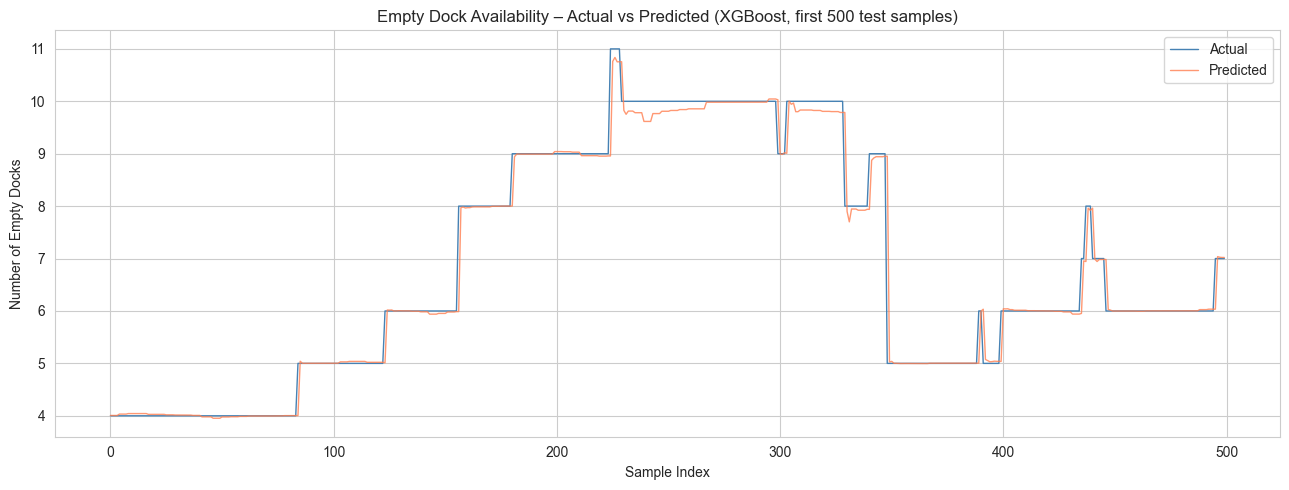

Plot saved.


In [19]:
# Plot actual vs predicted for empty docks
fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(y_docks_test.values[:sample], label='Actual', color='steelblue', linewidth=1)
ax.plot(docks_pred[:sample], label='Predicted', color='coral', linewidth=1, alpha=0.8)
ax.set_title('Empty Dock Availability – Actual vs Predicted (XGBoost, first 500 test samples)')
ax.set_xlabel('Sample Index')
ax.set_ylabel('Number of Empty Docks')
ax.legend()
plt.tight_layout()
plt.savefig('docks_actual_vs_predicted.png', dpi=150)
plt.show()
print('Plot saved.')

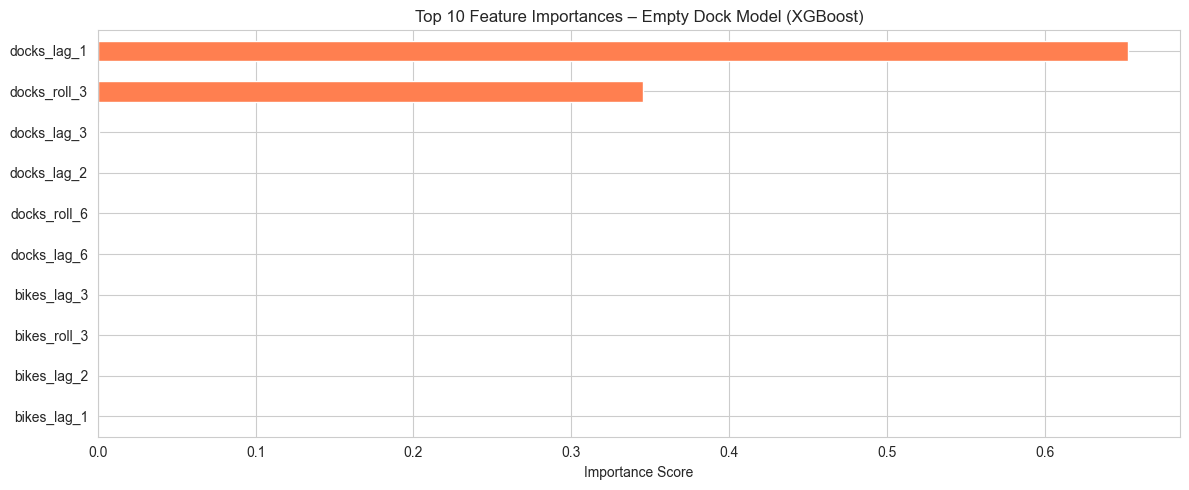

Plot saved.

Top 10 features:
docks_lag_1     0.652958
docks_roll_3    0.345661
docks_lag_3     0.000549
docks_lag_2     0.000159
docks_roll_6    0.000125
docks_lag_6     0.000065
bikes_lag_3     0.000057
bikes_roll_3    0.000048
bikes_lag_2     0.000045
bikes_lag_1     0.000045
dtype: float32


In [20]:
# Feature importance for dock model
importance_docks = pd.Series(xgb_docks.feature_importances_, index=feature_cols).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(12, 5))
importance_docks.head(10).sort_values().plot(kind='barh', color='coral', ax=ax)
ax.set_title('Top 10 Feature Importances – Empty Dock Model (XGBoost)')
ax.set_xlabel('Importance Score')
plt.tight_layout()
plt.savefig('docks_feature_importance.png', dpi=150)
plt.show()
print('Plot saved.')
print('\nTop 10 features:')
print(importance_docks.head(10))

## 8. Model Comparison Summary

In [22]:
summary = pd.DataFrame({
    'Model': ['XGBoost – Bike Availability', 'XGBoost – Empty Dock Availability'],
    'MAE':  [round(mae_bikes, 4),  round(mae_docks, 4)],
    'RMSE': [round(rmse_bikes, 4), round(rmse_docks, 4)],
    'R²':   [round(r2_bikes, 4),   round(r2_docks, 4)]
})

print('=== Model Performance Summary ===')
print(summary.to_string(index=False))

=== Model Performance Summary ===
                            Model    MAE   RMSE     R²
      XGBoost – Bike Availability 0.1363 0.4823 0.9901
XGBoost – Empty Dock Availability 0.1438 0.4839 0.9864


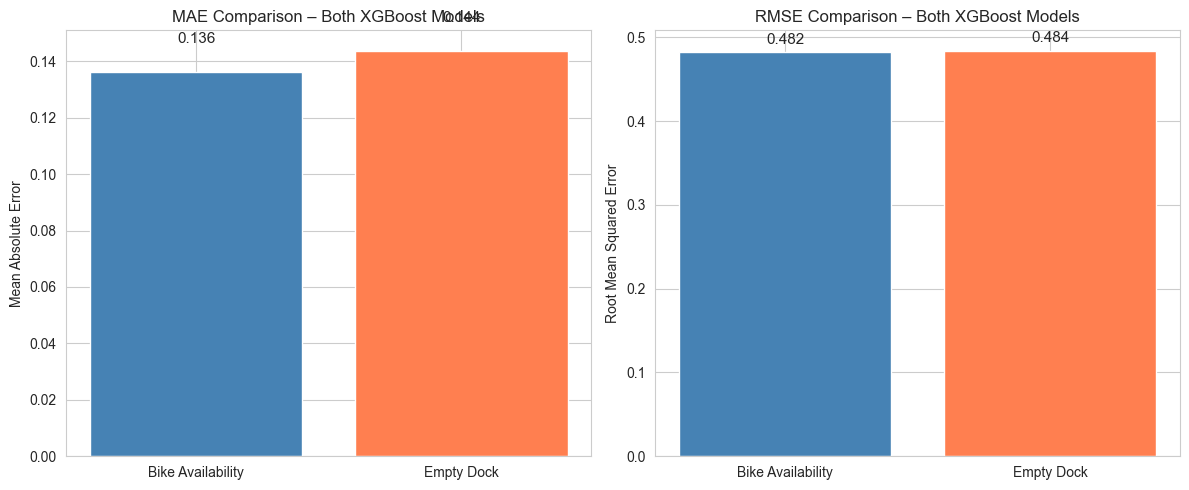

Plot saved.


In [23]:
# Bar chart comparing MAE and RMSE for both models
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

models = ['Bike Availability', 'Empty Dock']
maes   = [mae_bikes, mae_docks]
rmses  = [rmse_bikes, rmse_docks]

axes[0].bar(models, maes, color=['steelblue', 'coral'], edgecolor='white')
axes[0].set_title('MAE Comparison – Both XGBoost Models')
axes[0].set_ylabel('Mean Absolute Error')
for i, v in enumerate(maes):
    axes[0].text(i, v + 0.01, f'{v:.3f}', ha='center', fontsize=11)

axes[1].bar(models, rmses, color=['steelblue', 'coral'], edgecolor='white')
axes[1].set_title('RMSE Comparison – Both XGBoost Models')
axes[1].set_ylabel('Root Mean Squared Error')
for i, v in enumerate(rmses):
    axes[1].text(i, v + 0.01, f'{v:.3f}', ha='center', fontsize=11)

plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150)
plt.show()
print('Plot saved.')

## 9. Summary and Next Steps

Two XGBoost Gradient Boosting models were trained and evaluated:

- **Bike Availability Model**: predicts NBBIKES at each station using lag features, rolling averages, and time-based features
- **Empty Dock Model**: predicts NBEMPTYDOCKS using the same feature set

Both models used an 80/20 time-aware train/test split to prevent data leakage.
Feature importance analysis confirmed that the most recent lag values (lag_1, lag_2) and rolling averages are the strongest predictors for both targets.

**Next steps:**
- Hyperparameter tuning using cross-validation to improve model performance
- Evaluate performance broken down by station and by time of day
- Integrate both models into the final project output alongside the demand pattern analysis